# Brain Tumor MRI Classification

## CNN Training Notebook

This notebook performs:

- CNN Model Creation
- Model Compilation
- Model Training
- Validation
- Model Saving

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
BASE_DIR = Path("../datasets/classification")

TRAIN_DIR = BASE_DIR / "Training"

IMG_SIZE = (128,128)

BATCH_SIZE = 32

SEED = 42

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.


In [4]:
class_names = train_ds.class_names

print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [5]:
normalization_layer = tf.keras.layers.Rescaling(
    1./255
)

train_ds = train_ds.map(
    lambda x,y:
    (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x,y:
    (normalization_layer(x), y)
)

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)

val_ds = val_ds.prefetch(AUTOTUNE)

# Build CNN

In [7]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(
        16,
        (3,3),
        activation="relu",
        input_shape=(128,128,3)
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        4,
        activation="softmax"
    )

])

C:\Users\dipan\OneDrive\Desktop\BrainTumorAI\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,420 (126.64 KB)

 Trainable params: 32,420 (126.64 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [10]:
early_stop = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True

)

In [11]:
history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=20,

    callbacks=[early_stop]

)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - accuracy: 0.4292 - loss: 1.1945 - val_accuracy: 0.5116 - val_loss: 0.9870
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.6107 - loss: 0.9581 - val_accuracy: 0.6616 - val_loss: 0.8475
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step - accuracy: 0.6344 - loss: 0.8900 - val_accuracy: 0.6804 - val_loss: 0.8050
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.6772 - loss: 0.8147 - val_accuracy: 0.6938 - val_loss: 0.7304
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.6888 - loss: 0.7762 - val_accuracy: 0.6759 - val_loss: 0.7406
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - accuracy: 0.7022 - loss: 0.7391 - val_accuracy: 0.7652 - val_loss: 0.6195
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step - accuracy: 0.7230 - loss: 0.7023 - val_accuracy: 0.7482 - val_loss: 0.6303
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.7328 - loss: 0.6850 - 

In [12]:
model.save(
    "../models/brain_tumor_classifier.keras"
)

In [13]:
import os

print(
    os.path.exists(
        "../models/brain_tumor_classifier.keras"
    )
)

True


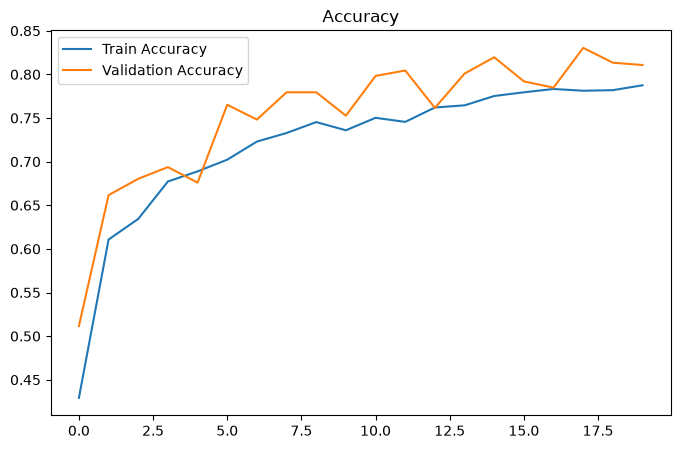

In [14]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.legend()

plt.title("Accuracy")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.legend()

plt.title("Loss")

plt.show()